In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file_path = r"C:\Users\Windows\OneDrive\Desktop\DAta cleaning\clean data.xlsx"

df = pd.read_excel(file_path)

In [5]:
print(df.head())
print(df.shape)
print(df.columns)

  Employee_ID       Full Name  Age Departments     Country  Join_Date  \
0     EMP1000       Bob Davis   25      Devops  California 2021-04-02   
1     EMP1001       Bob Brown   30     Finance       Texas 2020-07-10   
2     EMP1002     Alice Jones   30       Admin      Nevada 2023-12-07   
3     EMP1003       Eva Davis   25       Admin      Nevada 2021-11-27   
4     EMP1004  Frank Williams   25  Cloud Tech     Florida 2022-01-05   

      Salary                       Email       Phone Performance_Score  \
0   59767.65       bob.davis@example.com  1651623197           Average   
1   65304.66       bob.brown@example.com  1898471390         Excellent   
2   88145.90     alice.jones@example.com  5596363211              Good   
3   69450.99       eva.davis@example.com  3476490784              Good   
4  109324.61  frank.williams@example.com  1586734256              Poor   

   Remote_Work  
0         True  
1         True  
2         True  
3         True  
4        False  
(1020, 11)
Ind

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 1020
Number of columns: 11

Data Types:
Employee_ID                  object
Full Name                    object
Age                           int64
Departments                  object
Country                      object
Join_Date            datetime64[ns]
Salary                      float64
Email                        object
Phone                         int64
Performance_Score            object
Remote_Work                    bool
dtype: object

Missing Values:
Employee_ID           0
Full Name             0
Age                   0
Departments           0
Country               0
Join_Date             0
Salary               24
Email                 0
Phone                 0
Performance_Score     0
Remote_Work           0
dtype: int64


In [7]:
total_employees = df["Employee_ID"].nunique()

print("Total Employees:", total_employees)

Total Employees: 1020


In [10]:
department_counts = (
    df["Departments"]
    .value_counts()
    .sort_values(ascending=False)
)

print(department_counts)

Departments
Devops        189
Sales         178
Hr            171
Finance       170
Admin         166
Cloud Tech    146
Name: count, dtype: int64


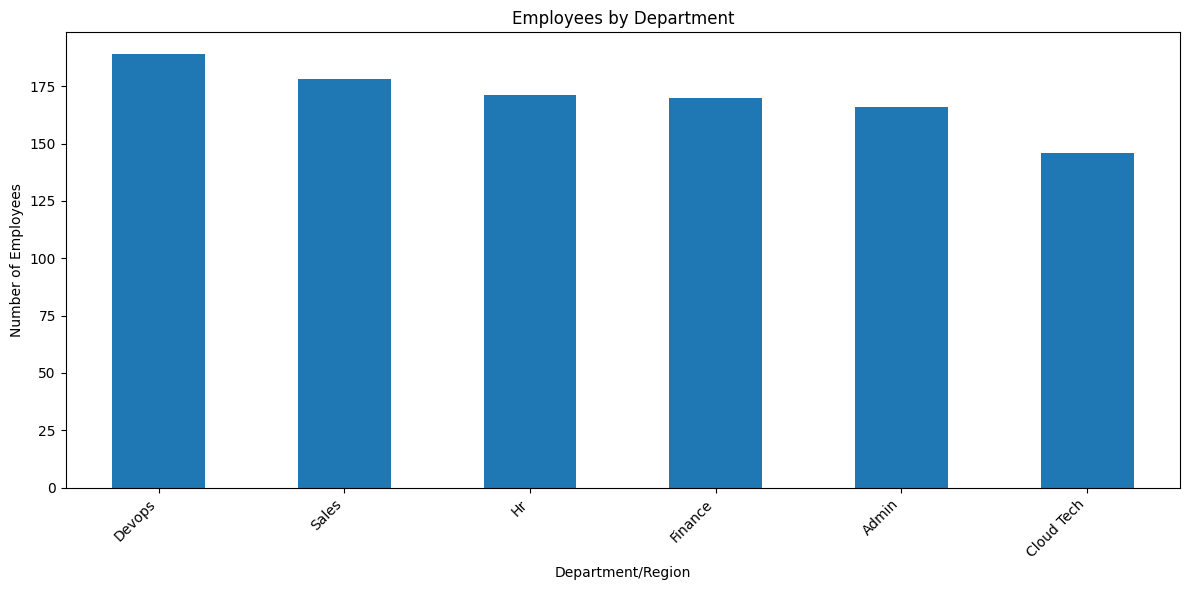

In [11]:
plt.figure(figsize=(12, 6))

department_counts.plot(kind="bar")

plt.title("Employees by Department")
plt.xlabel("Department/Region")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [12]:
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

In [13]:
salary_statistics = df["Salary"].describe()

print(salary_statistics)

count       996.000000
mean      85175.821225
std       19888.175050
min       50047.320000
25%       68392.487500
50%       85547.870000
75%      101037.130000
max      119971.650000
Name: Salary, dtype: float64


In [14]:
print("Average Salary:", round(df["Salary"].mean(), 2))
print("Minimum Salary:", df["Salary"].min())
print("Maximum Salary:", df["Salary"].max())

Average Salary: 85175.82
Minimum Salary: 50047.32
Maximum Salary: 119971.65


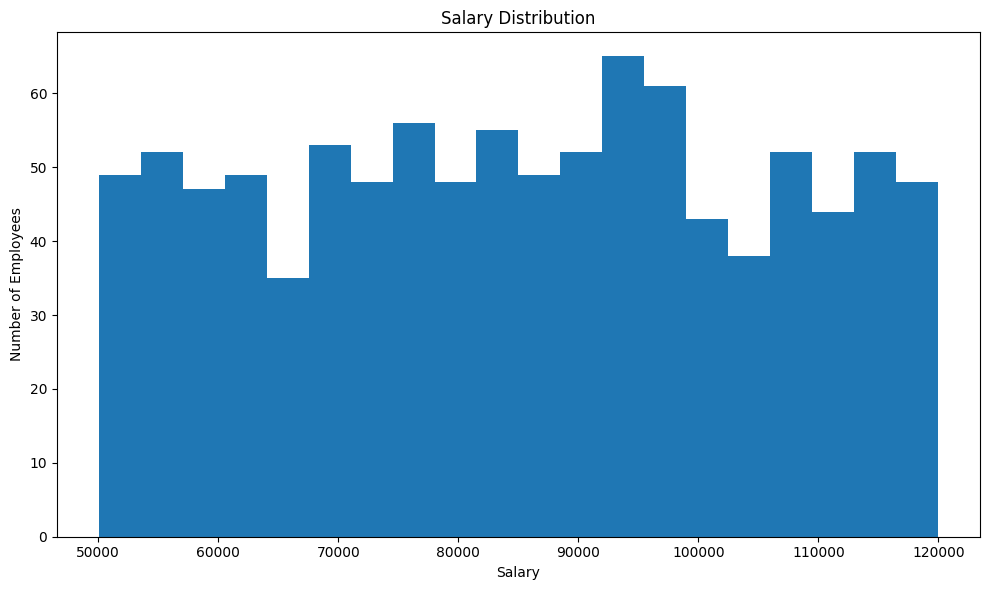

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(df["Salary"].dropna(), bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [16]:
performance_counts = df["Performance_Score"].value_counts()

print(performance_counts)

Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64


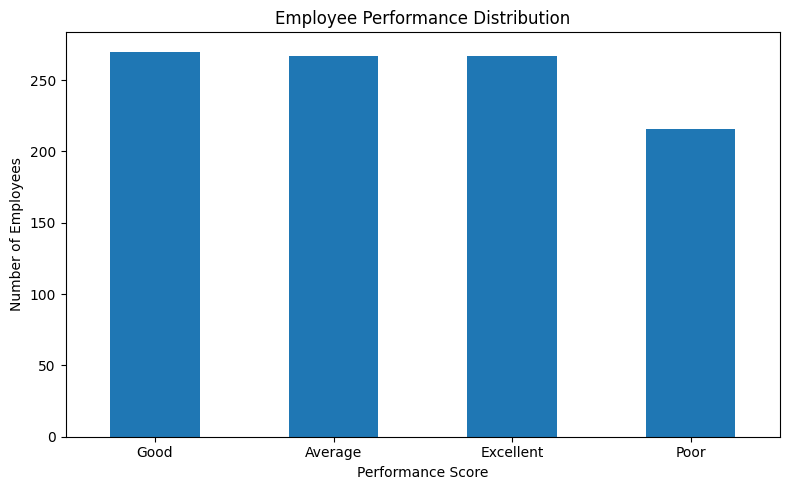

In [17]:
plt.figure(figsize=(8, 5))

performance_counts.plot(kind="bar")

plt.title("Employee Performance Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
remote_counts = df["Remote_Work"].value_counts()

print(remote_counts)

Remote_Work
True     513
False    507
Name: count, dtype: int64


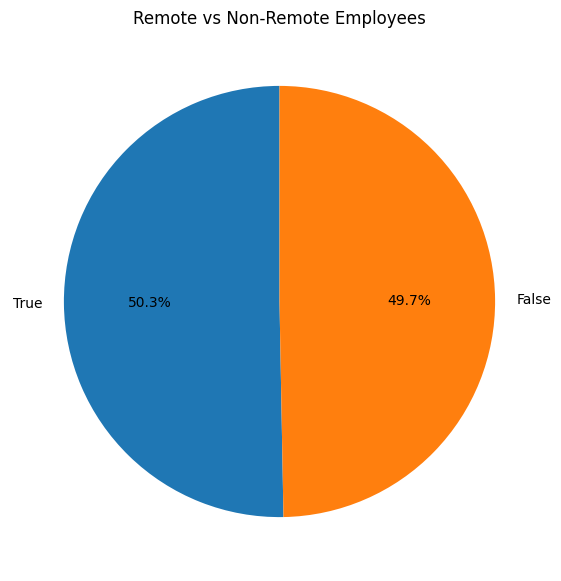

In [19]:
plt.figure(figsize=(7, 7))

remote_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Remote vs Non-Remote Employees")
plt.ylabel("")

plt.show()

In [20]:
df["Join_Date"] = pd.to_datetime(
    df["Join_Date"],
    errors="coerce"
)

In [21]:
joining_trends = (
    df["Join_Date"]
    .dt.year
    .value_counts()
    .sort_index()
)

print(joining_trends)

Join_Date
2020    203
2021    189
2022    183
2023    228
2024    217
Name: count, dtype: int64


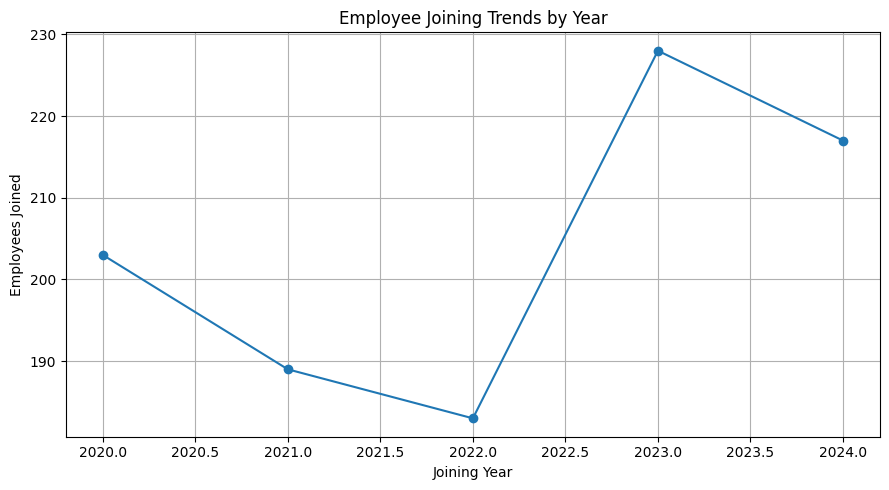

In [22]:
plt.figure(figsize=(9, 5))

joining_trends.plot(
    kind="line",
    marker="o"
)

plt.title("Employee Joining Trends by Year")
plt.xlabel("Joining Year")
plt.ylabel("Employees Joined")
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
age_anomalies = df[
    (df["Age"] < 18) |
    (df["Age"] > 70)
]

print("Age anomalies:", len(age_anomalies))
print(age_anomalies)

Age anomalies: 0
Empty DataFrame
Columns: [Employee_ID, Full Name, Age, Departments, Country, Join_Date, Salary, Email, Phone, Performance_Score, Remote_Work]
Index: []


In [24]:
negative_salary = df[df["Salary"] < 0]

print("Negative salary records:", len(negative_salary))
print(negative_salary)

Negative salary records: 0
Empty DataFrame
Columns: [Employee_ID, Full Name, Age, Departments, Country, Join_Date, Salary, Email, Phone, Performance_Score, Remote_Work]
Index: []


In [25]:
duplicate_ids = df[
    df["Employee_ID"].duplicated(keep=False)
]

print("Duplicate Employee ID records:", len(duplicate_ids))
print(duplicate_ids)

Duplicate Employee ID records: 0
Empty DataFrame
Columns: [Employee_ID, Full Name, Age, Departments, Country, Join_Date, Salary, Email, Phone, Performance_Score, Remote_Work]
Index: []


In [26]:
print(df[["Age", "Salary"]].describe())

               Age         Salary
count  1020.000000     996.000000
mean     31.970588   85175.821225
std       5.136901   19888.175050
min      25.000000   50047.320000
25%      30.000000   68392.487500
50%      30.000000   85547.870000
75%      35.000000  101037.130000
max      40.000000  119971.650000


In [27]:
correlation = df["Age"].corr(df["Salary"])

print("Age-Salary Correlation:", round(correlation, 2))

Age-Salary Correlation: 0.08


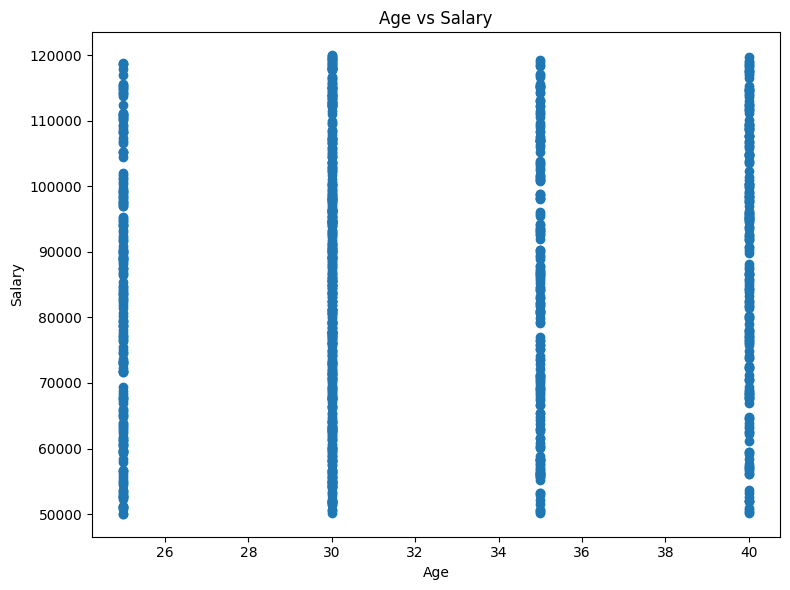

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Age"], df["Salary"])

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

In [30]:
salary_by_department = (
    df.groupby("Departments")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

print(salary_by_department)

Departments
Sales         87014.862571
Devops        86016.023641
Hr            85473.643174
Admin         85191.922795
Cloud Tech    84923.036241
Finance       82240.610417
Name: Salary, dtype: float64


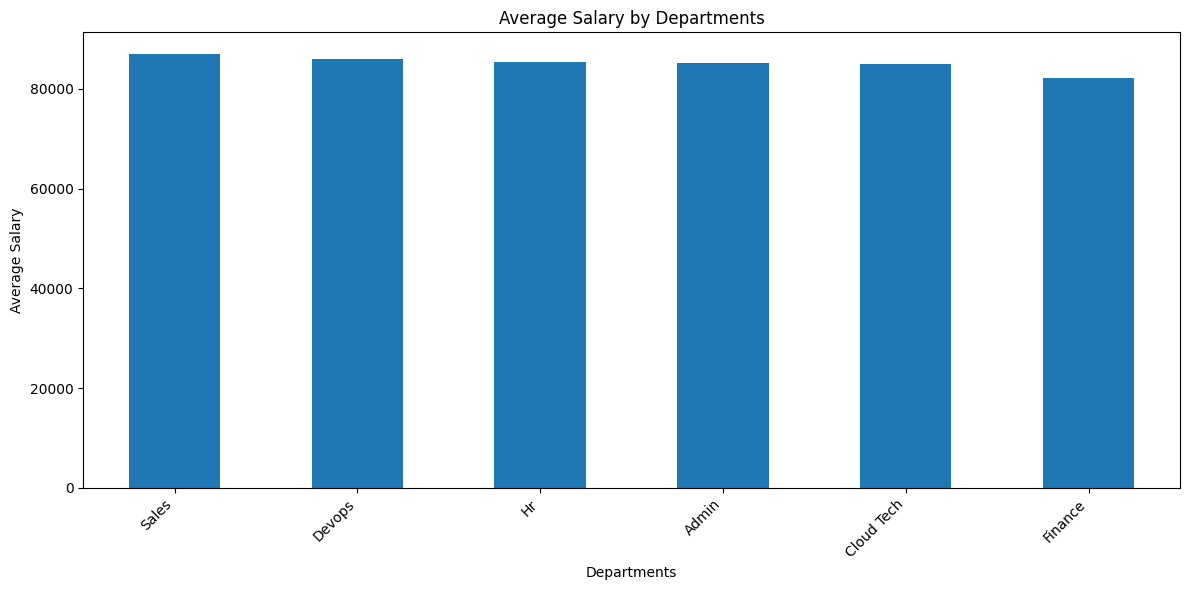

In [31]:
plt.figure(figsize=(12, 6))

salary_by_department.plot(kind="bar")

plt.title("Average Salary by Departments")
plt.xlabel("Departments")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [32]:
department_counts.to_csv("employees_by_department.csv")

performance_counts.to_csv("performance_distribution.csv")

remote_counts.to_csv("remote_work_distribution.csv")

joining_trends.to_csv("joining_trends.csv")

salary_by_department.to_csv("salary_by_department.csv")